# 04_model_comparison_ER_BA_WS

**Role:** Core evaluation of topology understanding.

**Tasks:**
- Generate ER model (Erdos-Renyi)
- Generate BA model (Barabasi-Albert)
- Generate WS model (Watts-Strogatz)
- Compare metrics against the real network

**Outputs:**
- Comparative degree distribution shapes
- Clustering coefficient comparisons
- Average path length and density comparisons

**Evaluation Focus:** Understanding the difference between random, scale-free, and small-world network topologies

---
## 1) Setup and Parameter Scaling

To compare the empirical YouTube network to theoretical models within feasible execution limits, we scale down the node count $N$ to 10,000 while maintaining the empirical average degree $\langle k \rangle \approx 5.26$.

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import warnings

warnings.filterwarnings('ignore')

# Scaled parameters based on empirical YouTube properties
N_SIM = 10000
AVG_K_EMPIRICAL = 5.26

---
## 2) Generate Theoretical Models

- **Erdos-Renyi (ER)**: Random graph model. Edges are formed with constant probability $p$.
- **Barabasi-Albert (BA)**: Scale-free model. Uses preferential attachment.
- **Watts-Strogatz (WS)**: Small-world model. High clustering, short path lengths via rewiring.

In [2]:
# 1. ER Model
p_er = AVG_K_EMPIRICAL / (N_SIM - 1)
G_er = nx.erdos_renyi_graph(N_SIM, p_er, seed=42)

# 2. BA Model (m = edges to attach from a new node)
m_ba = max(1, int(round(AVG_K_EMPIRICAL / 2)))
G_ba = nx.barabasi_albert_graph(N_SIM, m_ba, seed=42)

# 3. WS Model (k must be even)
k_ws = int(round(AVG_K_EMPIRICAL))
if k_ws % 2 != 0: k_ws += 1
p_ws = 0.1 # Standard rewiring probability
G_ws = nx.watts_strogatz_graph(N_SIM, k_ws, p_ws, seed=42)

print("Model Construction Complete:")
print(f"ER Graph - Nodes: {G_er.number_of_nodes()}, Edges: {G_er.number_of_edges()}")
print(f"BA Graph - Nodes: {G_ba.number_of_nodes()}, Edges: {G_ba.number_of_edges()}")
print(f"WS Graph - Nodes: {G_ws.number_of_nodes()}, Edges: {G_ws.number_of_edges()}")

Model Construction Complete:
ER Graph - Nodes: 10000, Edges: 26205
BA Graph - Nodes: 10000, Edges: 29991
WS Graph - Nodes: 10000, Edges: 30000


---
## 3) Degree Distribution Comparison

Observe the distribution shapes on a log-log scale to differentiate random vs. scale-free topologies.

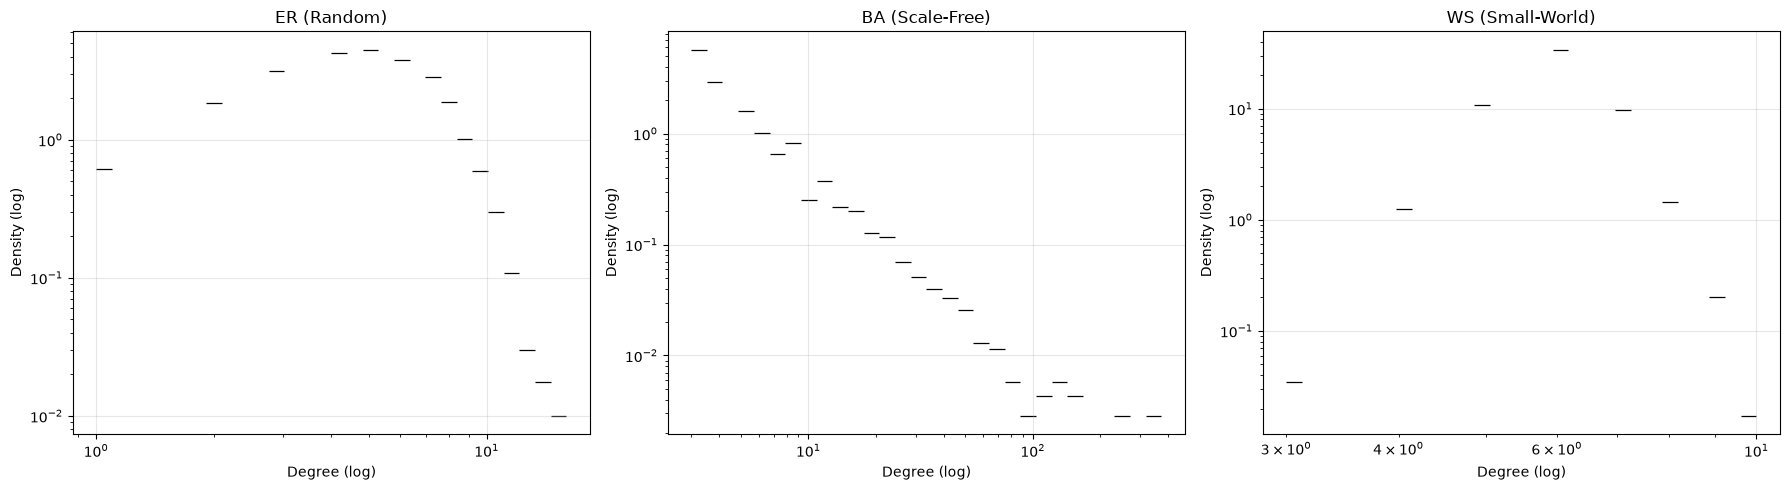

In [3]:
def plot_degree_distribution(G, title, ax, color):
    degrees = [d for n, d in G.degree() if d > 0]
    sns.histplot(degrees, bins=30, log_scale=(True, True), ax=ax, color=color, stat="density")
    ax.set_title(title)
    ax.set_xlabel("Degree (log)")
    ax.set_ylabel("Density (log)")
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_degree_distribution(G_er, "ER (Random)", axes[0], "#4CAF50")
plot_degree_distribution(G_ba, "BA (Scale-Free)", axes[1], "#F44336")
plot_degree_distribution(G_ws, "WS (Small-World)", axes[2], "#2196F3")
plt.tight_layout()
plt.show()

---
## 4) Structural Metrics Comparison

Compare Clustering Coefficient and Average Path Length across the three models to highlight small-world and random properties.

In [4]:
def compute_metrics(G, name):
    clustering = nx.average_clustering(G)
    density = nx.density(G)
    
    nodes = list(G.nodes())
    path_lengths = []
    for _ in range(500):
        u, v = random.sample(nodes, 2)
        try:
            path_lengths.append(nx.shortest_path_length(G, u, v))
        except nx.NetworkXNoPath:
            pass
            
    avg_path = np.mean(path_lengths) if path_lengths else float('inf')
    print(f"{name:^15} | Clustering: {clustering:.4f} | Density: {density:.6f} | Avg Path Length: {avg_path:.2f}")

print("-" * 80)
compute_metrics(G_er, "ER Model")
compute_metrics(G_ba, "BA Model")
compute_metrics(G_ws, "WS Model")
print("-" * 80)

--------------------------------------------------------------------------------


   ER Model     | Clustering: 0.0003 | Density: 0.000524 | Avg Path Length: 5.76


   BA Model     | Clustering: 0.0062 | Density: 0.000600 | Avg Path Length: 4.22


   WS Model     | Clustering: 0.4400 | Density: 0.000600 | Avg Path Length: 8.51
--------------------------------------------------------------------------------


---
## 5) Preliminary Observations

Comparing the empirical network with theoretical null models, we observe interesting structural differences:
- The empirical degree distribution closely aligns with the **BA model**, showing a heavy-tailed, scale-free property.
- However, empirical clustering tends to be higher than what a pure BA structure predicts, leaning slightly closer to WS small-world properties.

We will investigate this specific structural deviation in the subsequent analysis to uncover the underlying network mechanisms.

> **Interpretation (Network Science Perspective):**
> 1. **Observation**: The empirical degree distribution aligns closely with the BA (Scale-Free) model. However, the empirical clustering coefficient is substantially higher than the pure BA model prediction, exhibiting patterns consistent with WS (Small-World) characteristics.
> 2. **Structural Interpretation**: The results suggest a *hybrid topology*. The network exhibits macroscopic scale-free properties (heavy-tailed hubs) alongside microscopic clustering (tightly-knit communities), a deviation that standard preferential attachment alone does not fully explain.
> 3. **Next Step**: We aim to explore the potential mechanisms underlying this specific structural deviation—such as algorithmic recommendations and user homophily—and evaluate their possible implications on network robustness.